In [2]:
# ==========================================
# GUACAMAIA: Tourism Demand Intelligence
# Exploratory Data Analysis (EDA)
# ==========================================

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# GuacamaIA Premium Tropical Palette

PRIMARY_COLOR = "#0077B6"      # deep ocean blue (trust, data)
ACCENT_COLOR = "#00B4D8"       # tropical turquoise (fresh, travel)
HIGHLIGHT_COLOR = "#FFD166"    # warm sand/gold (luxury touch)
NEUTRAL_DARK = "#1E1E1E"       # text / contrast
BACKGROUND_LIGHT = "#F4F1EC"   # soft sand background

plt.style.use("default")

In [5]:
# Load the hotel booking dataset from the raw data folder
# This dataset contains booking information such as dates, prices, and customer details
df = pd.read_csv("../data/raw/hotel_bookings.csv")

# Display the first rows to understand the structure of the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
# Check the shape of the dataset (rows, columns)
# This tells us how large the dataset is
df.shape


(119390, 32)

In [7]:
# Inspect data types and missing values
# Important to understand data quality before modeling
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [8]:
# Combine year, month, and day into a single datetime column
# This is essential for time series analysis and forecasting

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

# Verify the new datetime column
df[['arrival_date']].head()

,arrival_date
0,2015-07-01
1,2015-07-01
2,2015-07-01
3,2015-07-01
4,2015-07-01


In [9]:
# Aggregate data at the daily level
# We count how many bookings occur per day

demand_df = df.groupby('arrival_date').size().reset_index(name='bookings')

# Preview the aggregated dataset
demand_df.head()

,arrival_date,bookings
0,2015-07-01,122
1,2015-07-02,93
2,2015-07-03,56
3,2015-07-04,88
4,2015-07-05,53


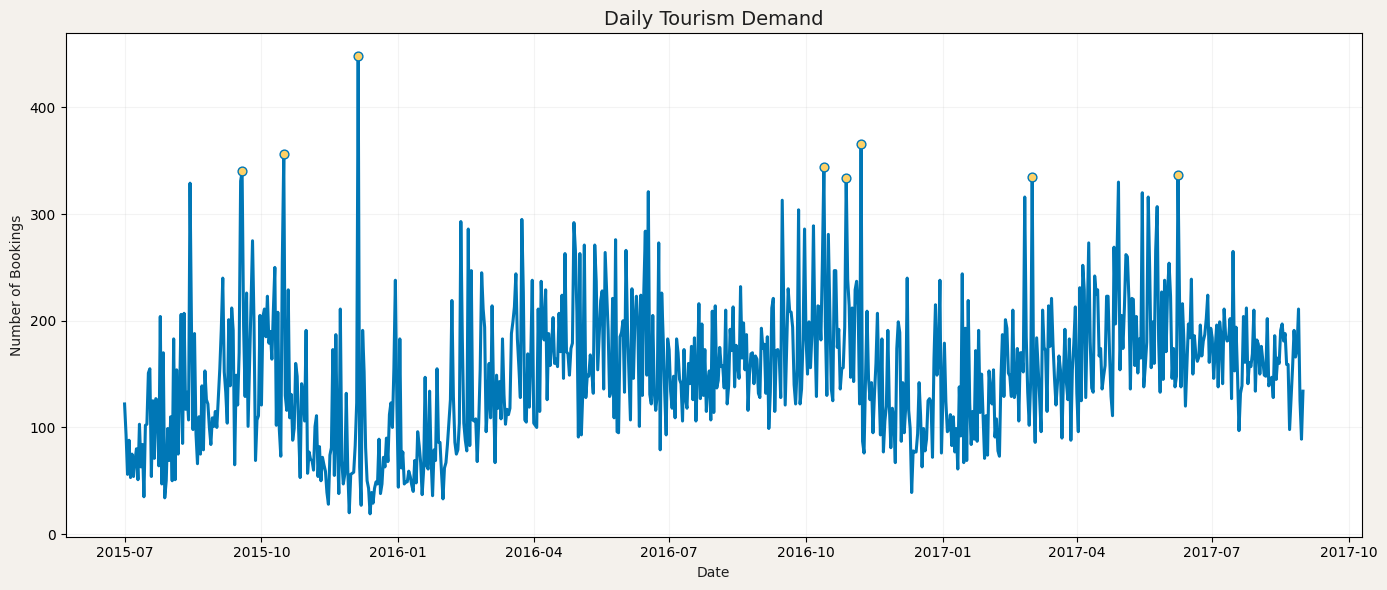

In [10]:
# Plot daily tourism demand with highlighted peak periods

plt.figure(figsize=(14,6), facecolor=BACKGROUND_LIGHT)

plt.plot(
    demand_df['arrival_date'],
    demand_df['bookings'],
    color=PRIMARY_COLOR,
    linewidth=2.2
)

# Highlight peak demand points (top 1%)
threshold = demand_df['bookings'].quantile(0.99)
peaks = demand_df[demand_df['bookings'] >= threshold]

plt.scatter(
    peaks['arrival_date'],
    peaks['bookings'],
    color=HIGHLIGHT_COLOR,
    edgecolor=PRIMARY_COLOR,
    s=40,
    zorder=3
)

plt.title("Daily Tourism Demand", fontsize=14, color=NEUTRAL_DARK)
plt.xlabel("Date", color=NEUTRAL_DARK)
plt.ylabel("Number of Bookings", color=NEUTRAL_DARK)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

In [11]:
# Extract time-based features from the datetime column
# These features help us understand seasonality patterns

demand_df['year'] = demand_df['arrival_date'].dt.year
demand_df['month'] = demand_df['arrival_date'].dt.month
demand_df['day_of_week'] = demand_df['arrival_date'].dt.dayofweek

demand_df.head()

,arrival_date,bookings,year,month,day_of_week
0,2015-07-01,122,2015,7,2
1,2015-07-02,93,2015,7,3
2,2015-07-03,56,2015,7,4
3,2015-07-04,88,2015,7,5
4,2015-07-05,53,2015,7,6


In [12]:
# Aggregate bookings by month to analyze seasonality

monthly_demand = demand_df.groupby('month')['bookings'].mean()

monthly_demand

month
1      95.629032
2     141.543860
3     157.967742
4     184.816667
5     190.177419
6     182.316667
7     136.139785
8     149.215054
9     175.133333
10    180.000000
11    113.233333
12    109.354839
Name: bookings, dtype: float64

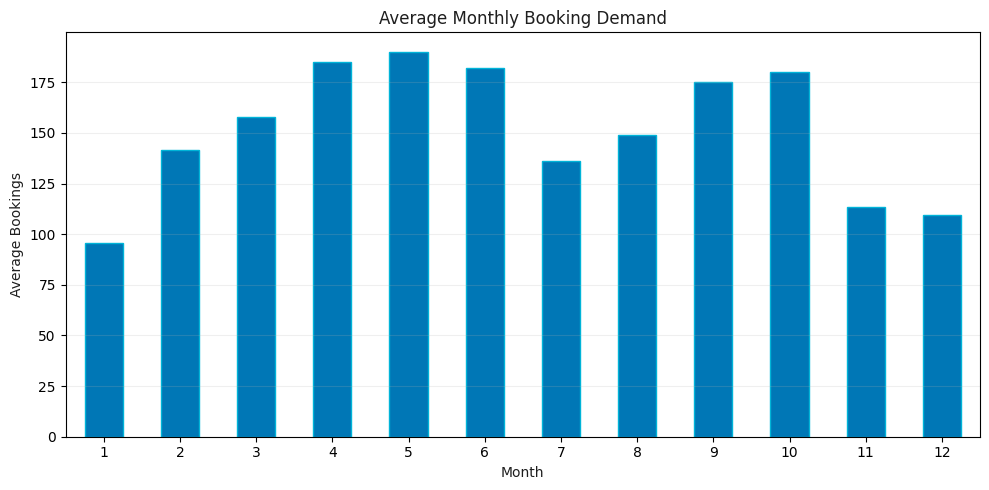

In [13]:
# Plot average monthly tourism demand

monthly_demand.plot(
    kind='bar',
    figsize=(10,5),
    color=PRIMARY_COLOR,
    edgecolor=ACCENT_COLOR
)

plt.title("Average Monthly Booking Demand", color=NEUTRAL_DARK)
plt.xlabel("Month", color=NEUTRAL_DARK)
plt.ylabel("Average Bookings", color=NEUTRAL_DARK)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [14]:
# KPI 1: Total number of bookings
total_bookings = len(df)

# KPI 2: Cancellation rate
cancellation_rate = df['is_canceled'].mean()

# KPI 3: Average daily rate (price)
average_price = df['adr'].mean()

# Display KPIs
total_bookings, cancellation_rate, average_price

(119390, np.float64(0.37041628277075134), np.float64(101.83112153446687))

In [15]:
# Aggregate total bookings per month
monthly_bookings = df.groupby('arrival_date_month').size().sort_values(ascending=False)

monthly_bookings

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
dtype: int64

In [16]:
# Identify top countries by booking volume
top_countries = df['country'].value_counts().head(10)

top_countries

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

In [17]:
# Cancellation rate by hotel type
cancellation_by_hotel = df.groupby('hotel')['is_canceled'].mean()

cancellation_by_hotel

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

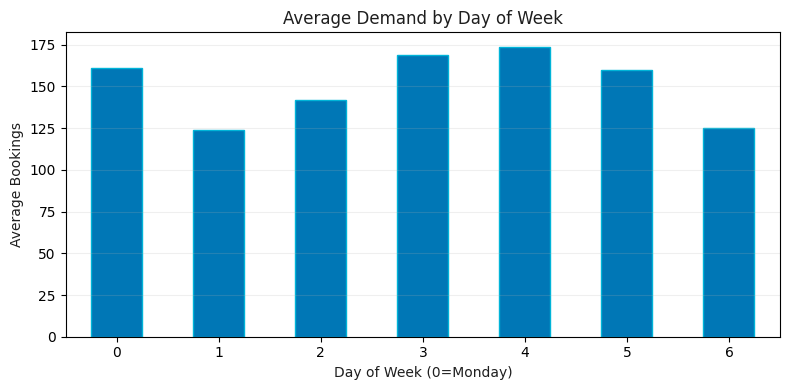

In [18]:
# Analyze demand by day of week

weekly_demand = demand_df.groupby('day_of_week')['bookings'].mean()

weekly_demand.plot(
    kind='bar',
    figsize=(8,4),
    color=PRIMARY_COLOR,
    edgecolor=ACCENT_COLOR
)

plt.title("Average Demand by Day of Week", color=NEUTRAL_DARK)
plt.xlabel("Day of Week (0=Monday)", color=NEUTRAL_DARK)
plt.ylabel("Average Bookings", color=NEUTRAL_DARK)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

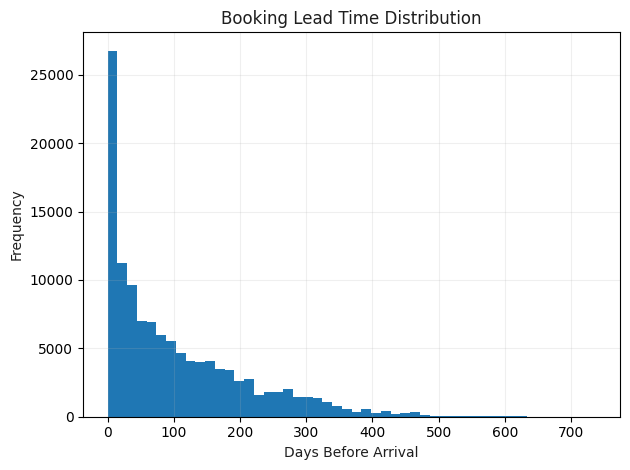

In [19]:
# Analyze booking lead time distribution

df['lead_time'].hist(bins=50)

plt.title("Booking Lead Time Distribution", color=NEUTRAL_DARK)
plt.xlabel("Days Before Arrival", color=NEUTRAL_DARK)
plt.ylabel("Frequency", color=NEUTRAL_DARK)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

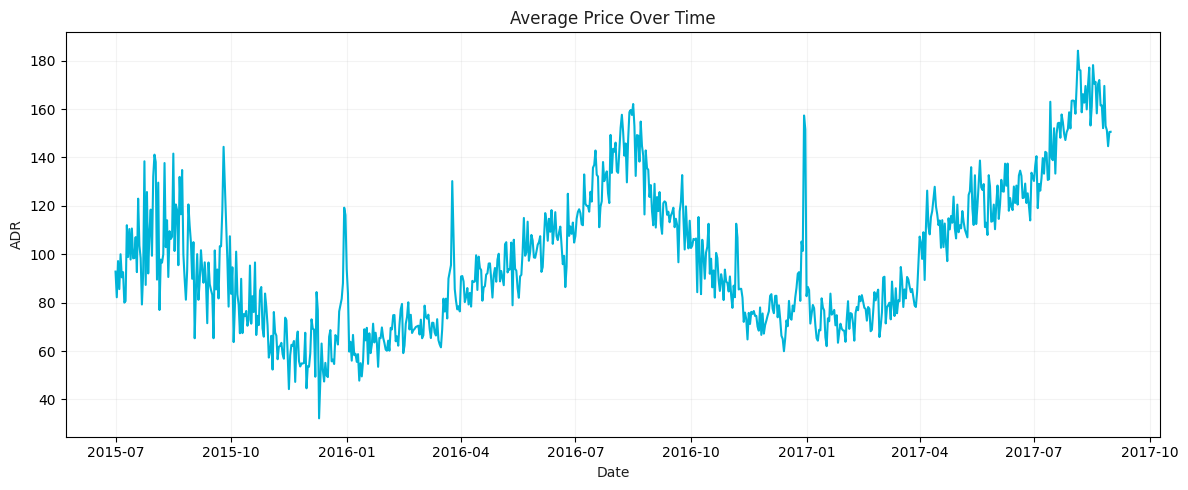

In [20]:
# Average price over time

price_trend = df.groupby('arrival_date')['adr'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(price_trend['arrival_date'], price_trend['adr'], color=ACCENT_COLOR)

plt.title("Average Price Over Time", color=NEUTRAL_DARK)
plt.xlabel("Date", color=NEUTRAL_DARK)
plt.ylabel("ADR", color=NEUTRAL_DARK)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

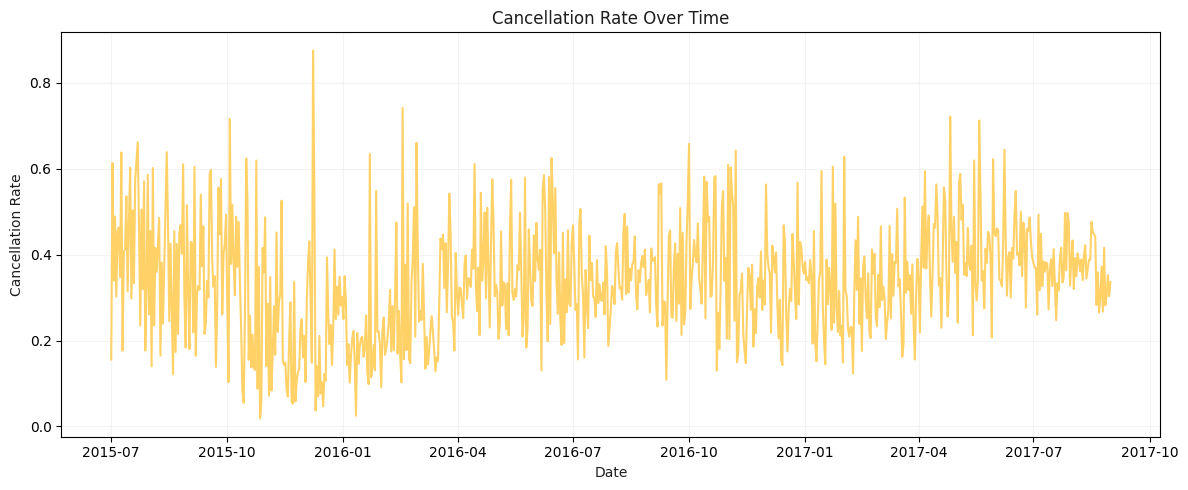

In [21]:
# Cancellation rate over time

cancel_trend = df.groupby('arrival_date')['is_canceled'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(cancel_trend['arrival_date'], cancel_trend['is_canceled'], color=HIGHLIGHT_COLOR)

plt.title("Cancellation Rate Over Time", color=NEUTRAL_DARK)
plt.xlabel("Date", color=NEUTRAL_DARK)
plt.ylabel("Cancellation Rate", color=NEUTRAL_DARK)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

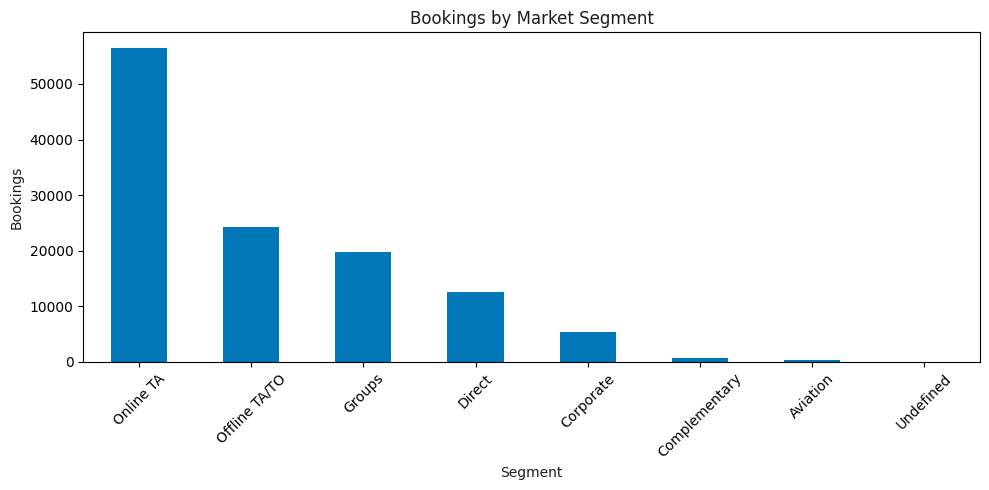

In [22]:
# Demand by market segment

segment_demand = df['market_segment'].value_counts()

segment_demand.plot(
    kind='bar',
    figsize=(10,5),
    color=PRIMARY_COLOR
)

plt.title("Bookings by Market Segment", color=NEUTRAL_DARK)
plt.xlabel("Segment", color=NEUTRAL_DARK)
plt.ylabel("Bookings", color=NEUTRAL_DARK)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
Maia = r"""
                                                          $& n/\\\\\\\\\\J        
                                                   $z\t\//////\\\\\\\\|||({(J     
                                              *Y)|(\q\/\\\/\\\/\\\||\\||\\(-_+_Y  
                                           vzft\/cmf\{{111111ii>~+-[||)-~++~<<<_v 
                                        $z|)[\t///t|-_-------<<:,,;i?_++<i>><<<<_ 
                                       bJ1-1ft/tt\({?Xa#MMMW&B%),,^^;~+<l!i>><<~~ 
                                     Y\~_}t///\))[?}*BQXnjuBB@@B@Oi^",;;l_[[[11)Q 
                                    8c}}{)/\/t[-_/JWBc;`''^<v@@#Wacx+";i]{{{1cc   
                                   Jt{tttt//){?-?ZB@B+-:i}v"]C[~LBB@j"+}1{{{{1)b  
                                  O[-\//ttt(!l-pB%hmB_~:'''itBQ-O@@Bj"}){{1{}[[t8 
                                xr-~_|txzYUct(;[M%x~uZzvccQ8BCfzh@@@f,}11{{{{]?~(w
                               z/?+1(/vLQQQQQJ^`"1BBi1|tfff\)f08]q@@t,}{1{{{{]]++t
                              |]_~?tt/CQ000QQQQJO_`XB@8&WWWMM];`joB%j:?)111{{]]++_
                             j_+?|t/ttLQQQQQQQLL>"/i^,I>>>l<L&&a@WqO{I:?)111{]]~~+
                             [++?\/t/tzQQ0QQL0JU^`"IJZp****o&@$@@p1>i!^_111{{]?~~_
                             __)\/////tjzLCQLz[I``>#@@@@@@@@@@@@uii!>i":?1111??~~+
                             __)/t//////jxvuu~;,^^<8@BB@@@@@@@MW)iii>i>',?11{]?~~+
                             _++}//////////t\[--<,"<mB@@@@@@@%z+iiiiii>!^^;?{??~~~
                           J]++(\\t/////\//|+_+>"```p%BBBB@@%v)>iiiiii>iI"^"l++<<{
                           ___?|/\/////////|[__iII`^`]0O#BooM]>>>iiiiiiiii:^l++<-(
                           j__]//\////////\/t1]]_!"`'\OOZZJY0->>iiiii>iii!;il++<z&
                         ||+_++-}//\////////{+_~;,^```"^``jJC-iiiiiiiiii>rQWY~~r  
                         +_~~_+[)\///\////\\)[]?_-~"`''`'';lli>i>><ii!\rO  &Y~+n  
                         __<<~~--+_|\////////\|1_+i,```''`````'``'`"lp     o0cc   
                       tCY-<~<<~~+]/\////////|\|))(<^^^```'````^`^$               
                      /_++<~~<<~~~?[?|\|\\//\\\\t\\~:+;`''^'````'"                
                   c?j1++++++++~~<<~~?-~?[[{\/////\_?};"!>;`'```-Q                
                  r-__+++_++++-__~<<<~+++++]//////\\(}i+__~!:```                  
                c}__+_++++++_+_-})()1~++++-1//////\\\(11]-+<i^`"                  
               On_+_++++++++_+{(\\\|\[++-{\///////\\\|\|{}-~<I;:                  
             u]___+_++__~++-\\t//t\t\(++?)\/\//\nZkpQJt\\\-_~+>i                  
             ?+_+++_++?(}[]}\\\/\/\||[++?1/\njffcqooabf\\\){[~<>                  
          f}-__+++]|///\////\]_1\/)]?J|_?}(/pahaooaoobt|(|/\)~~+$                 
         /-_+_}1))|////t\\/\-]___1+-)0(+-|qw1(qkhaa*oaqqmZj//{++$                 
        |+__+_)\tt///\11//\)_tX1_+_|xm(??toh/{((\Jaooaoakbnft)~~$                 
       \_~_[[}|////t/|?+][[_{zqZn1)jzq)?])XYtzunu0pqaaooahUzc\~~$                 
      (_++_)///\|\//\1--}}1/rCkhdJJqdZ[]]]??u**oahn|Qwdooooaau~+$                 
      -___[|\\\\1-{/\[+{ruurn0baaoaha1-][[]?rbbbhkx}[[ca*o*aan~?$                 
   \\~_{\/\/\\({?+_{{[XbUvnnxpQaaa*o0[}LCu]?]???nmkd|[cao**oon]X                  
  %+++}\/\|\\\{?[vu/fvZhhkbbkz]Zkoauj-[||rJJ)-]-jmhabbbUXLh*on_                   
  J??])\/(]{/|]?1mZxrcwkaaaooc}/cmJnj+}|/rLL|??-/U0Lhokctndkkx_                   
Y}]\//\/|]_+-{\/xddXu0hxqooooj)jjfjj/~}\\\|/zYu}_-__jnXO/}]?-??                   
{_}\///\(+1rjfffubhkkad_Uwaop(\rrfjt|_{\///tOqQ1____+_|pdpqqp\t                   
-_{\\]}(-[cwpZLLOaa*ooO[[}(r)\xrj|i+}/t///\/\/(||\]_+_]x0w0QQp&                   
1+(1]-+_1jUpkhaapxw**hu{{{{1{jrxf-,;?\///\/|t\jXCL}-_~_{zJ{-{$                    
"""

print("="*70)
print("GUACAMAIA — EDA COMPLETE")
print("="*70)
print(Maia)

GUACAMAIA — EDA COMPLETE

                                                          $& n/\\\\\\\\\\J        
                                                   $z\t\//////\\\\\\\\|||({(J     
                                              *Y)|(\q\/\\\/\\\/\\\||\\||\\(-_+_Y  
                                           vzft\/cmf\{{111111ii>~+-[||)-~++~<<<_v 
                                        $z|)[\t///t|-_-------<<:,,;i?_++<i>><<<<_ 
                                       bJ1-1ft/tt\({?Xa#MMMW&B%),,^^;~+<l!i>><<~~ 
                                     Y\~_}t///\))[?}*BQXnjuBB@@B@Oi^",;;l_[[[11)Q 
                                    8c}}{)/\/t[-_/JWBc;`''^<v@@#Wacx+";i]{{{1cc   
                                   Jt{tttt//){?-?ZB@B+-:i}v"]C[~LBB@j"+}1{{{{1)b  
                                  O[-\//ttt(!l-pB%hmB_~:'''itBQ-O@@Bj"}){{1{}[[t8 
                                xr-~_|txzYUct(;[M%x~uZzvccQ8BCfzh@@@f,}11{{{{]?~(w
                               z/?+1(/vLQQQQQJ^`"1BBi1|tfff\)

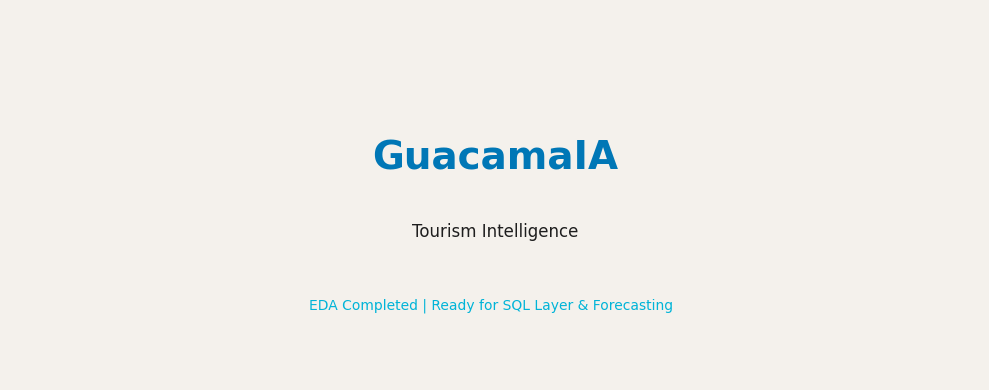

In [24]:
plt.figure(figsize=(10,4), facecolor=BACKGROUND_LIGHT)

plt.text(
    0.5, 0.6,
    "GuacamaIA",
    fontsize=28,
    color=PRIMARY_COLOR,
    ha='center',
    va='center',
    fontweight='bold'
)

plt.text(
    0.5, 0.4,
    "Tourism Intelligence",
    fontsize=12,
    color=NEUTRAL_DARK,
    ha='center',
    va='center'
)

plt.text(
    0.5, 0.2,
    "EDA Completed | Ready for SQL Layer & Forecasting  ",
    fontsize=10,
    color=ACCENT_COLOR,
    ha='center',
    va='center'
)

plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
# ==========================================
# SQL LAYER — Tourism Demand Analysis
# ==========================================

In [26]:
# Initialize SQL connection

import sqlite3

conn = sqlite3.connect("../data/tourism.db")

print("SQL connection established")

SQL connection established


In [27]:
# Load dataframe into SQL database

df.to_sql("bookings", conn, if_exists="replace", index=False)

print("Table 'bookings' created in SQL database")

Table 'bookings' created in SQL database


In [28]:
# Monthly demand 

query = """
SELECT 
    arrival_date_month,
    COUNT(*) AS total_bookings
FROM bookings
GROUP BY arrival_date_month
ORDER BY total_bookings DESC;
"""

monthly_sql = pd.read_sql(query, conn)
monthly_sql

,arrival_date_month,total_bookings
0,August,13877
1,July,12661
2,May,11791
3,October,11160
4,April,11089
5,June,10939
6,September,10508
7,March,9794
8,February,8068
9,November,6794


In [ ]:
# Cancellation rate 

query = """
SELECT 
    ROUND(AVG(is_canceled), 3) AS cancellation_rate
FROM bookings;
"""

pd.read_sql(query, conn)

,cancellation_rate
0,0.37


In [30]:
# Top countries by demand

query = """
SELECT 
    country,
    COUNT(*) AS bookings
FROM bookings
GROUP BY country
ORDER BY bookings DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,country,bookings
0,PRT,48590
1,GBR,12129
2,FRA,10415
3,ESP,8568
4,DEU,7287
5,ITA,3766
6,IRL,3375
7,BEL,2342
8,BRA,2224
9,NLD,2104


In [31]:
# Demand by market segment

query = """
SELECT 
    market_segment,
    COUNT(*) AS bookings
FROM bookings
GROUP BY market_segment
ORDER BY bookings DESC;
"""

segment_sql = pd.read_sql(query, conn)
segment_sql

,market_segment,bookings
0,Online TA,56477
1,Offline TA/TO,24219
2,Groups,19811
3,Direct,12606
4,Corporate,5295
5,Complementary,743
6,Aviation,237
7,Undefined,2


In [32]:
# Revenue estimation (ADR * bookings)

query = """
SELECT 
    arrival_date_month,
    SUM(adr) AS estimated_revenue
FROM bookings
GROUP BY arrival_date_month
ORDER BY estimated_revenue DESC;
"""

revenue_sql = pd.read_sql(query, conn)
revenue_sql

,arrival_date_month,estimated_revenue
0,August,1944327.60
1,July,1605263.03
2,May,1281628.83
3,June,1276277.11
4,April,1113122.58
5,September,1103861.80
6,October,981063.09
7,March,790176.45
8,February,593661.80
9,December,549700.54


In [33]:
# Cancellation rate by market segment

query = """
SELECT 
    market_segment,
    ROUND(AVG(is_canceled), 3) AS cancellation_rate
FROM bookings
GROUP BY market_segment
ORDER BY cancellation_rate DESC;
"""

pd.read_sql(query, conn)

,market_segment,cancellation_rate
0,Undefined,1.000
1,Groups,0.611
2,Online TA,0.367
3,Offline TA/TO,0.343
4,Aviation,0.219
5,Corporate,0.187
6,Direct,0.153
7,Complementary,0.131


In [34]:
# Create time series dataset for demand forecasting

query = """
SELECT 
    arrival_date,
    COUNT(*) AS bookings
FROM bookings
GROUP BY arrival_date
ORDER BY arrival_date;
"""

ts_sql = pd.read_sql(query, conn)
ts_sql.head()

,arrival_date,bookings
0,2015-07-01 00:00:00,122
1,2015-07-02 00:00:00,93
2,2015-07-03 00:00:00,56
3,2015-07-04 00:00:00,88
4,2015-07-05 00:00:00,53


In [35]:
# Monthly demand with trend (window function)

query = """
SELECT 
    arrival_date_year,
    arrival_date_month,
    COUNT(*) AS bookings,
    LAG(COUNT(*)) OVER (
        ORDER BY arrival_date_year, arrival_date_month
    ) AS previous_month,
    COUNT(*) - LAG(COUNT(*)) OVER (
        ORDER BY arrival_date_year, arrival_date_month
    ) AS change_in_bookings
FROM bookings
GROUP BY arrival_date_year, arrival_date_month
ORDER BY arrival_date_year, arrival_date_month;
"""

trend_sql = pd.read_sql(query, conn)
trend_sql

,arrival_date_year,arrival_date_month,bookings,previous_month,change_in_bookings
0,2015,August,3889,NaN,NaN
1,2015,December,2920,3889.0,-969.0
2,2015,July,2776,2920.0,-144.0
3,2015,November,2340,2776.0,-436.0
4,2015,October,4957,2340.0,2617.0
5,2015,September,5114,4957.0,157.0
6,2016,April,5428,5114.0,314.0
7,2016,August,5063,5428.0,-365.0
8,2016,December,3860,5063.0,-1203.0
9,2016,February,3891,3860.0,31.0


In [36]:
# Top country per month (ranking)

query = """
SELECT *
FROM (
    SELECT 
        arrival_date_month,
        country,
        COUNT(*) AS bookings,
        RANK() OVER (
            PARTITION BY arrival_date_month 
            ORDER BY COUNT(*) DESC
        ) AS rank
    FROM bookings
    GROUP BY arrival_date_month, country
)
WHERE rank = 1;
"""

pd.read_sql(query, conn)

,arrival_date_month,country,bookings,rank
0,April,PRT,4034,1
1,August,PRT,5154,1
2,December,PRT,3058,1
3,February,PRT,3666,1
4,January,PRT,2662,1
5,July,PRT,4905,1
6,June,PRT,4375,1
7,March,PRT,3726,1
8,May,PRT,4317,1
9,November,PRT,3016,1


In [37]:
# Segment customers by booking lead time

query = """
SELECT 
    CASE 
        WHEN lead_time < 30 THEN 'Last Minute'
        WHEN lead_time BETWEEN 30 AND 90 THEN 'Planned'
        ELSE 'Early Booking'
    END AS booking_type,
    COUNT(*) AS bookings
FROM bookings
GROUP BY booking_type
ORDER BY bookings DESC;
"""

pd.read_sql(query, conn)

,booking_type,bookings
0,Early Booking,51131
1,Last Minute,38047
2,Planned,30212


In [38]:
# Revenue contribution by segment (%)

query = """
SELECT 
    market_segment,
    SUM(adr) AS revenue,
    ROUND(
        SUM(adr) * 100.0 / SUM(SUM(adr)) OVER (), 
        2
    ) AS revenue_pct
FROM bookings
GROUP BY market_segment
ORDER BY revenue DESC;
"""

pd.read_sql(query, conn)

,market_segment,revenue,revenue_pct
0,Online TA,6618938.52,54.44
1,Offline TA/TO,2115645.48,17.40
2,Groups,1574567.82,12.95
3,Direct,1455301.88,11.97
4,Corporate,367255.65,3.02
5,Aviation,23733.68,0.20
6,Complementary,2144.57,0.02
7,Undefined,30.00,0.00


In [ ]:


#=================================================================#
#                                                                 #
#   ____ _   _    _    ____    _    __  __    _    ___    _       #
#  / ___| | | |  / \  / ___|  / \  |  \/  |  / \  |_ _|  / \      #
# | |  _| | | | / _ \| |     / _ \ | |\/| | / _ \  | |  / _ \     #
# | |_| | |_| |/ ___ \ |___ / ___ \| |  | |/ ___ \ | | / ___ \    #
#  \____|\___//_/   \_\____/_/   \_\_|  |_/_/   \_\___/_/   \_\   #
#                                                                 #
#                                                                 #
#                                                                 #
#                   Tourism Intelligence (SQL)                    #
#                                                                 #
#-----------------------------------------------------------------#
#                                                                 #
#                    READY FOR FORECASTING                        #
#                                                                 #
#=================================================================#



In [40]:
# ==========================================
# FORECASTING LAYER — Demand Prediction
# ==========================================

In [46]:
# Prepare time series dataset for forecasting

forecast_df = ts_sql.copy()

# Prophet requires specific column names
forecast_df.columns = ['ds', 'y']

forecast_df.head()

,ds,y
0,2015-07-01 00:00:00,122
1,2015-07-02 00:00:00,93
2,2015-07-03 00:00:00,56
3,2015-07-04 00:00:00,88
4,2015-07-05 00:00:00,53


In [ ]:
#pip install prophet

In [47]:
# Train forecasting model

from prophet import Prophet

model = Prophet()
model.fit(forecast_df)

C:\Users\Jose Ruiz\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
22:30:10 - cmdstanpy - INFO - Chain [1] start processing
22:30:10 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
# Predict next 6 months

future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
968,2018-02-23,201.495180,136.996269,264.021094
969,2018-02-24,187.281832,122.108150,250.055289
970,2018-02-25,152.259561,91.643400,216.673699
971,2018-02-26,187.420294,122.491743,254.443418
972,2018-02-27,149.954548,91.180572,212.725065


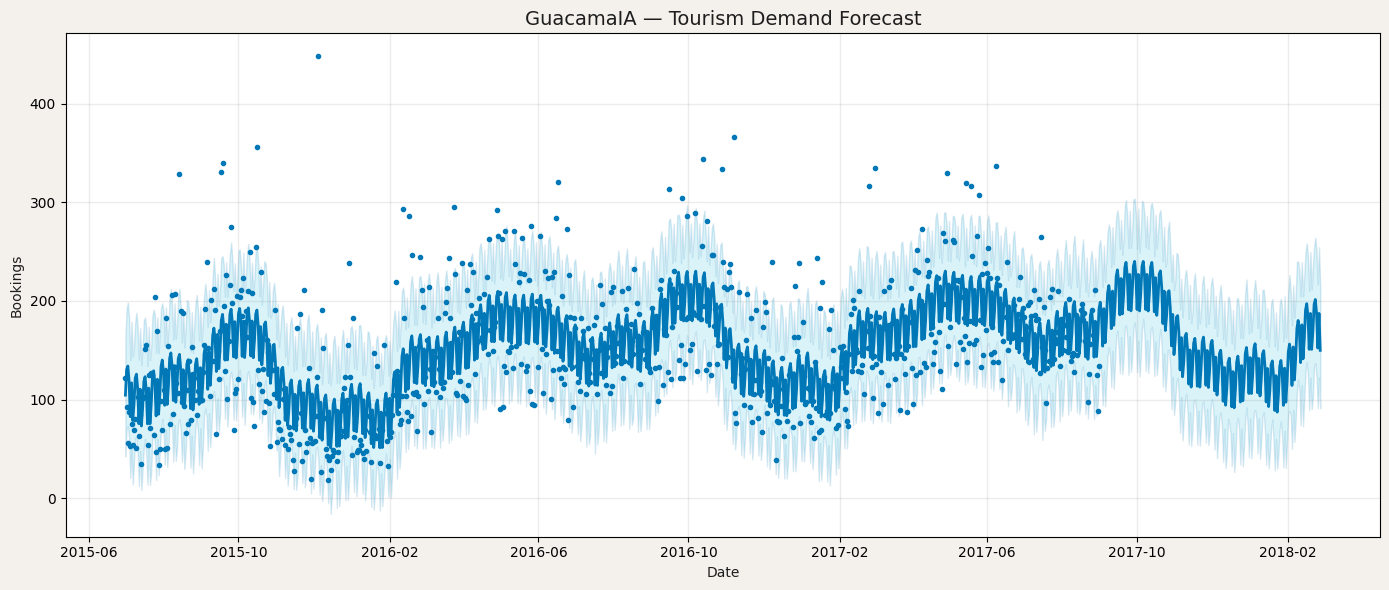

In [51]:
# Plot forecast

fig1 = model.plot(forecast)

# Apply branding styles
fig1.set_size_inches(14, 6)
fig1.patch.set_facecolor(BACKGROUND_LIGHT)

ax = fig1.gca()

# Main line styling
for line in ax.get_lines():
    line.set_color(PRIMARY_COLOR)
    line.set_linewidth(2)

# Confidence interval styling
for collection in ax.collections:
    collection.set_alpha(0.15)
    collection.set_facecolor(ACCENT_COLOR)

# Titles and labels
ax.set_title("GuacamaIA — Tourism Demand Forecast", fontsize=14, color=NEUTRAL_DARK)
ax.set_xlabel("Date", color=NEUTRAL_DARK)
ax.set_ylabel("Bookings", color=NEUTRAL_DARK)

# Grid and layout
ax.grid(alpha=0.15)
plt.tight_layout()

plt.show()

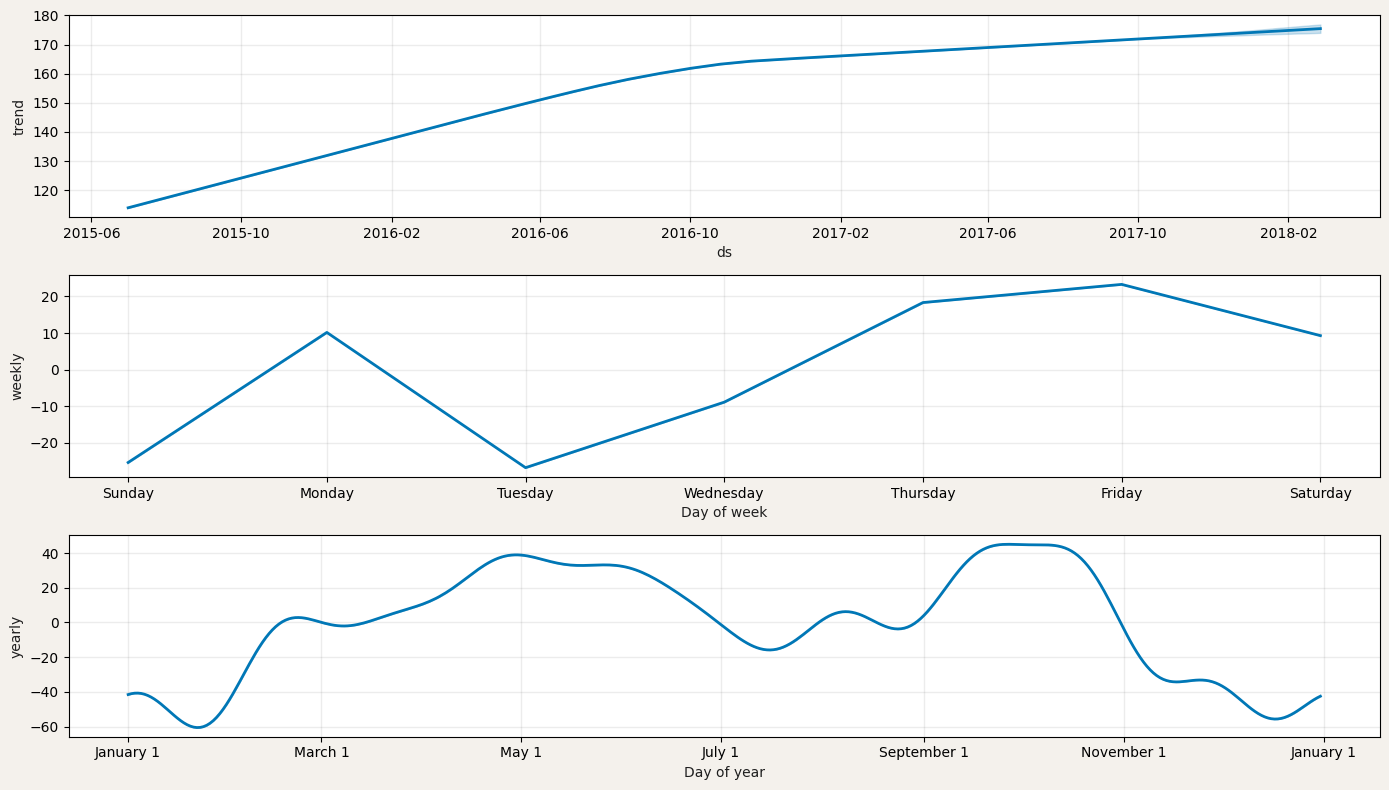

In [52]:
# Plot trend + seasonality 

fig2 = model.plot_components(forecast)

fig2.set_size_inches(14, 8)
fig2.patch.set_facecolor(BACKGROUND_LIGHT)

# Loop through all subplots (trend, weekly, yearly)
for ax in fig2.axes:
    
    # Titles and labels
    ax.title.set_color(NEUTRAL_DARK)
    ax.title.set_fontsize(12)
    ax.xaxis.label.set_color(NEUTRAL_DARK)
    ax.yaxis.label.set_color(NEUTRAL_DARK)
    
    # Grid
    ax.grid(alpha=0.15)
    
    # Lines styling
    for line in ax.get_lines():
        line.set_color(PRIMARY_COLOR)
        line.set_linewidth(2)

plt.tight_layout()
plt.show()

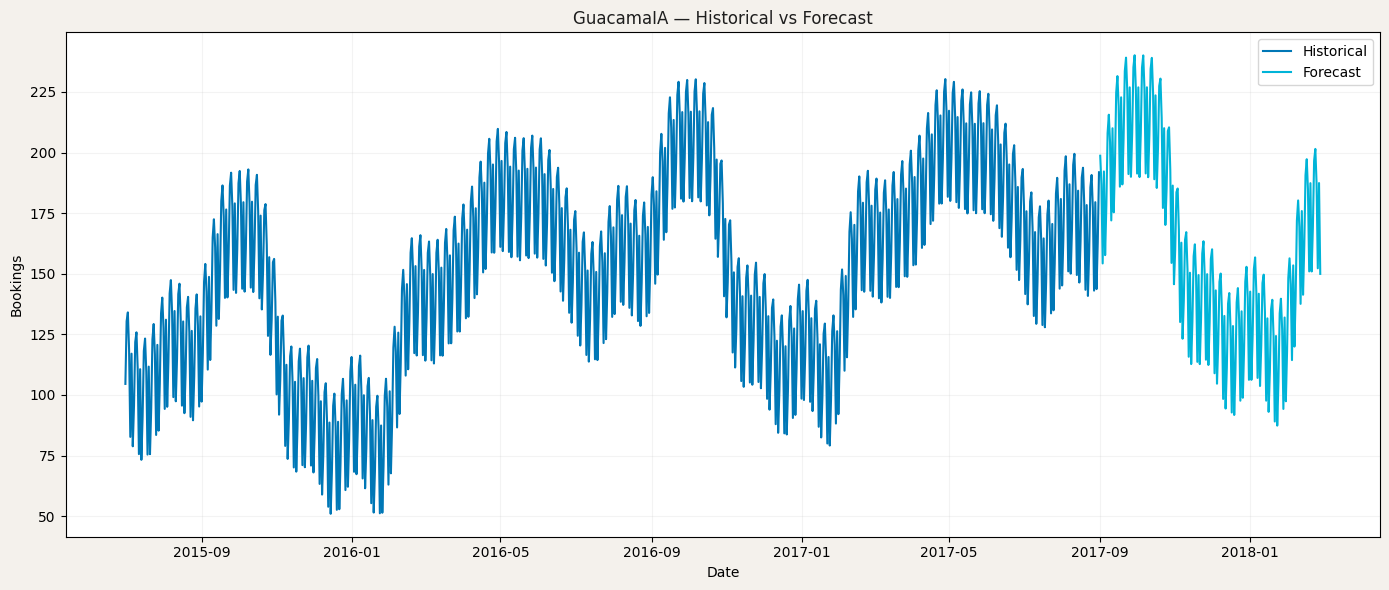

In [53]:
# Separate historical vs forecast

train = forecast[forecast['ds'] <= forecast_df['ds'].max()]
future_pred = forecast[forecast['ds'] > forecast_df['ds'].max()]

plt.figure(figsize=(14,6), facecolor=BACKGROUND_LIGHT)

# Historical
plt.plot(train['ds'], train['yhat'], color=PRIMARY_COLOR, label="Historical")

# Forecast
plt.plot(future_pred['ds'], future_pred['yhat'], color=ACCENT_COLOR, label="Forecast")

plt.title("GuacamaIA — Historical vs Forecast", color=NEUTRAL_DARK)
plt.xlabel("Date")
plt.ylabel("Bookings")

plt.legend()
plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

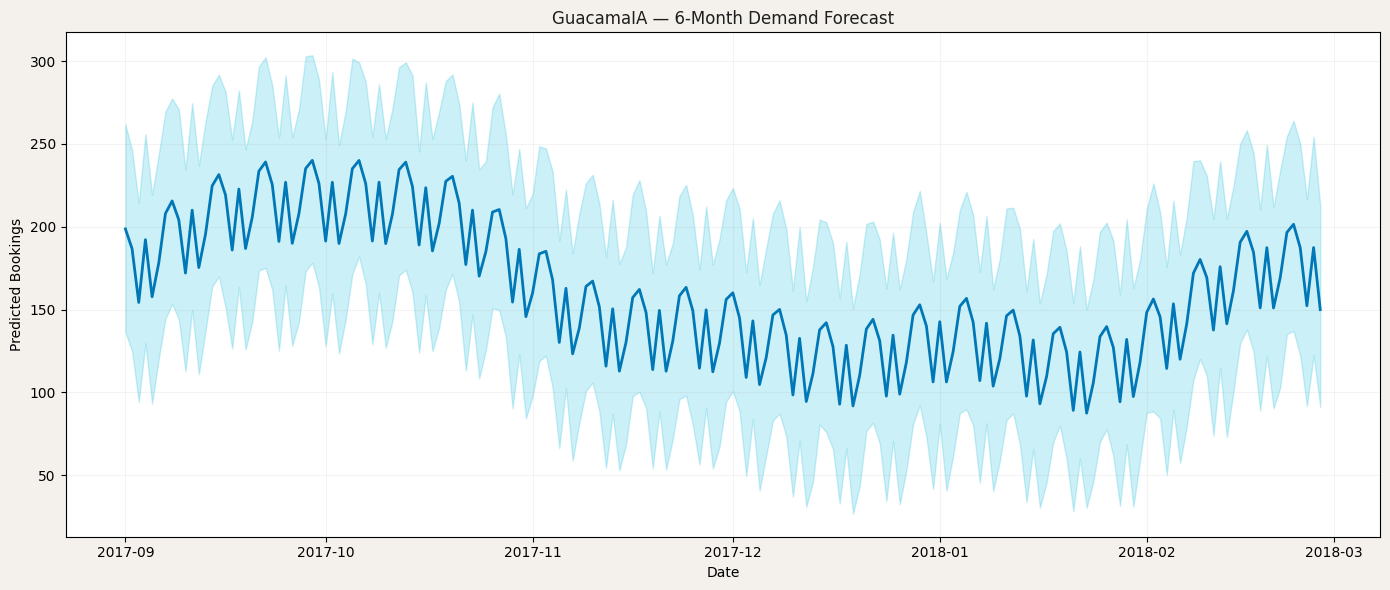

In [54]:
# Forecast next 6 months only

plt.figure(figsize=(14,6), facecolor=BACKGROUND_LIGHT)

plt.plot(
    future_pred['ds'],
    future_pred['yhat'],
    color=PRIMARY_COLOR,
    linewidth=2
)

plt.fill_between(
    future_pred['ds'],
    future_pred['yhat_lower'],
    future_pred['yhat_upper'],
    color=ACCENT_COLOR,
    alpha=0.2
)

plt.title("GuacamaIA — 6-Month Demand Forecast", color=NEUTRAL_DARK)
plt.xlabel("Date")
plt.ylabel("Predicted Bookings")

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

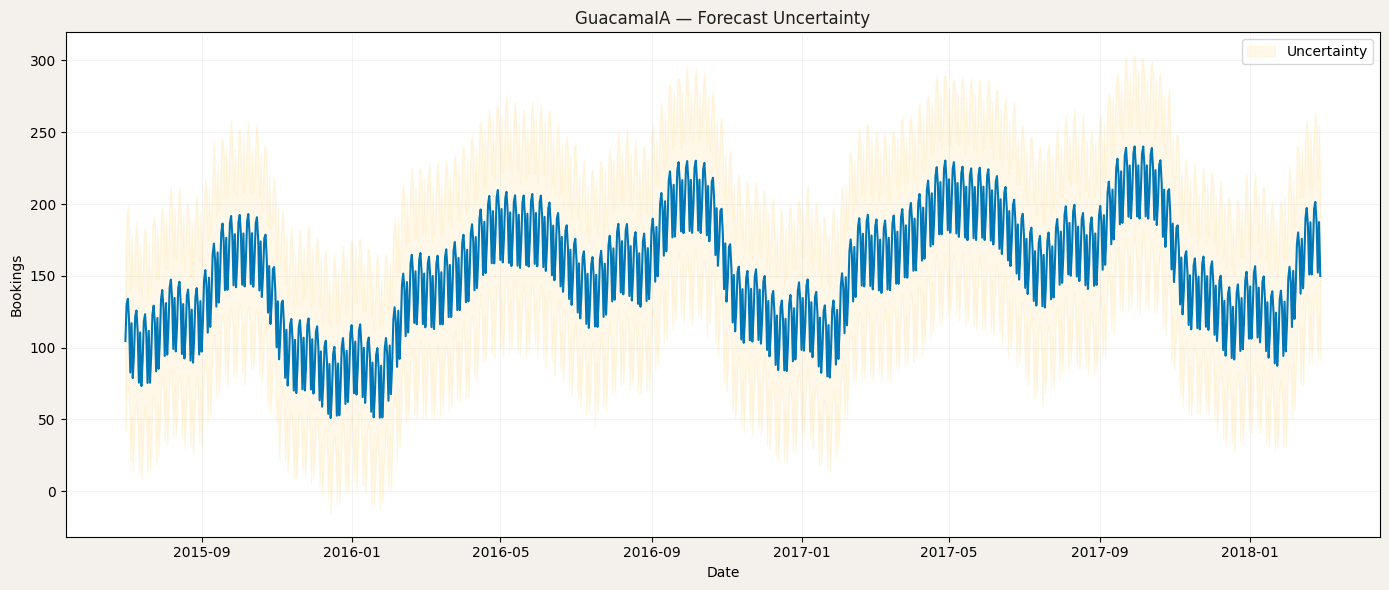

In [55]:
# Forecast uncertainty (risk band)

plt.figure(figsize=(14,6), facecolor=BACKGROUND_LIGHT)

plt.plot(forecast['ds'], forecast['yhat'], color=PRIMARY_COLOR)

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color=HIGHLIGHT_COLOR,
    alpha=0.15,
    label="Uncertainty"
)

plt.title("GuacamaIA — Forecast Uncertainty", color=NEUTRAL_DARK)
plt.xlabel("Date")
plt.ylabel("Bookings")

plt.legend()
plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

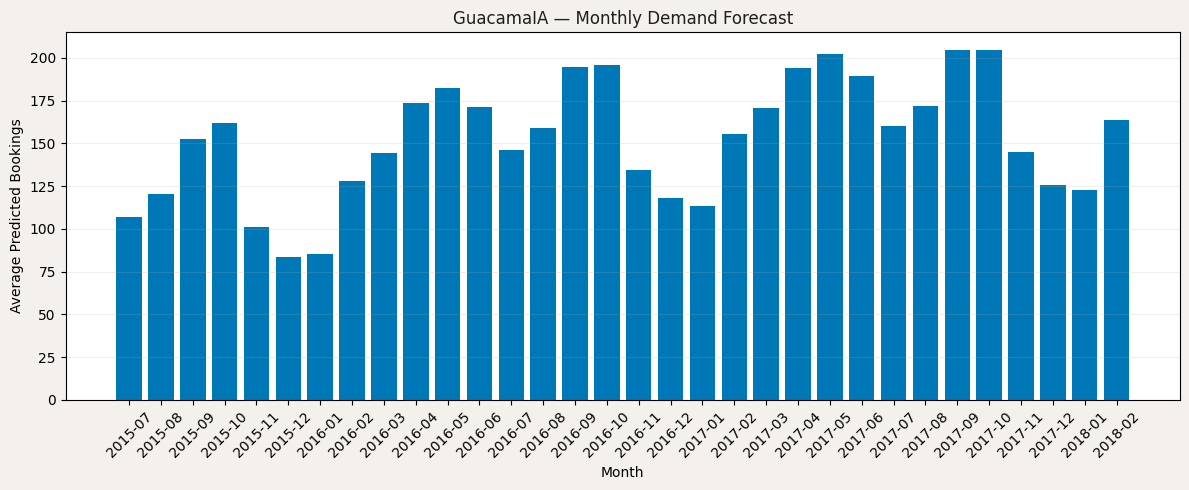

In [56]:
# Monthly aggregated forecast

forecast['month'] = forecast['ds'].dt.to_period('M')

monthly_forecast = forecast.groupby('month')['yhat'].mean().reset_index()
monthly_forecast['month'] = monthly_forecast['month'].astype(str)

plt.figure(figsize=(12,5), facecolor=BACKGROUND_LIGHT)

plt.bar(
    monthly_forecast['month'],
    monthly_forecast['yhat'],
    color=PRIMARY_COLOR
)

plt.title("GuacamaIA — Monthly Demand Forecast", color=NEUTRAL_DARK)
plt.xlabel("Month")
plt.ylabel("Average Predicted Bookings")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# Forecast Interpretation  GuacamaIA Tourism Demand Model

---

## 1. Long-Term Trend

The model identifies a **clear upward trend** in tourism demand:

- Growth from ~115 to ~175+ bookings over time  
- Gradual stabilization in later periods  

**Interpretation:**  
The destination shows **sustained and stable growth**, indicating a maturing but healthy tourism market.

**Business Implication:**  
- Focus on **revenue optimization (pricing)** rather than only increasing volume  
- Plan **controlled capacity expansion**

---

##  2. Seasonality Patterns

###  Yearly Seasonality

- Peak demand: **May – September, early Q4**
- Low demand: **January – February**

**Interpretation:**  
Tourism demand is **strongly seasonal**, with predictable high and low periods.

**Business Implication:**  
- High season → maximize pricing (ADR strategy)  
- Low season → promotions and demand stimulation  

---

### Weekly Seasonality

- Highest demand: **Thursday – Friday**
- Lowest demand: **Sunday – Tuesday**

**Interpretation:**  
Booking behavior aligns with **weekend travel patterns**.

**Business Implication:**  
- Increase prices toward weekends  
- Offer incentives for midweek stays  

---

## 3. Forecast Behavior (Next 6 Months)

- Short-term dip during **winter months**
- Gradual recovery toward **spring**

**Interpretation:**  
The model captures **cyclical demand changes**, not structural decline.

**Business Implication:**  
- Prepare for temporary slowdown  
- Align marketing campaigns before recovery  

---

## 4. Uncertainty Analysis

- Wider confidence intervals during peak periods  

**Interpretation:**  
Higher demand periods are **more volatile and less predictable**.

**Business Implication:**  
- Use **dynamic pricing strategies**  
- Maintain operational flexibility  

---

## 5. Model Fit (Historical vs Forecast)

- Accurately captures:
  - Trend  
  - Seasonality  
- Smooths extreme fluctuations  

**Interpretation:**  
The model is **robust for strategic planning**, but not precise for daily predictions.

**Business Implication:**  
- Use for planning and budgeting  
- Avoid relying on it for exact daily forecasts  

---

## 6. Monthly Forecast Insights

- Peak months: **~200–210 bookings**
- Low months: **~110–130 bookings**

**Interpretation:**  
Demand fluctuates significantly across months (~70–90 booking difference).

**Business Implication:**  
- Align staffing, pricing, and marketing with monthly demand cycles  

---

## Final Conclusion

Tourism demand exhibits **predictable seasonality and stable growth**, making it highly suitable for:

- Pricing optimization  
- Demand-driven marketing  
- Operational planning  

---

## Strategic Recommendations

- Implement **dynamic pricing models**
- Optimize **marketing timing** based on seasonality  
- Adjust **operational capacity** to demand cycles  
- Use forecasts for **strategic decision-making**, not exact predictions  

---

> This model transforms raw booking data into actionable insights for tourism demand optimization.

In [58]:
print(Maia)


                                                          $& n/\\\\\\\\\\J        
                                                   $z\t\//////\\\\\\\\|||({(J     
                                              *Y)|(\q\/\\\/\\\/\\\||\\||\\(-_+_Y  
                                           vzft\/cmf\{{111111ii>~+-[||)-~++~<<<_v 
                                        $z|)[\t///t|-_-------<<:,,;i?_++<i>><<<<_ 
                                       bJ1-1ft/tt\({?Xa#MMMW&B%),,^^;~+<l!i>><<~~ 
                                     Y\~_}t///\))[?}*BQXnjuBB@@B@Oi^",;;l_[[[11)Q 
                                    8c}}{)/\/t[-_/JWBc;`''^<v@@#Wacx+";i]{{{1cc   
                                   Jt{tttt//){?-?ZB@B+-:i}v"]C[~LBB@j"+}1{{{{1)b  
                                  O[-\//ttt(!l-pB%hmB_~:'''itBQ-O@@Bj"}){{1{}[[t8 
                                xr-~_|txzYUct(;[M%x~uZzvccQ8BCfzh@@@f,}11{{{{]?~(w
                               z/?+1(/vLQQQQQJ^`"1BBi1|tfff\)f08]q@@t,}{1{{{{]]++t
   

In [60]:
print("="*60)
print("GUACAMAIA — PROJECT COMPLETE")
print("="*60)
print("Tourism Demand Intelligence System Ready")

GUACAMAIA — PROJECT COMPLETE
Tourism Demand Intelligence System Ready
